# Disease Prediction from Symptoms using Machine Learning a Flask App

In [7]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout, Input, Layer
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import re
import tensorflow as tf
from sklearn.metrics import precision_score, recall_score, f1_score

# Custom Attention Layer
class AttentionLayer(Layer):
    def __init__(self):
        super(AttentionLayer, self).__init__()

    def build(self, input_shape):
        self.W = self.add_weight(name='attention_weight', shape=(input_shape[-1], input_shape[-1]), initializer='glorot_uniform', trainable=True)
        self.b = self.add_weight(name='attention_bias', shape=(input_shape[-1],), initializer='zeros', trainable=True)
        self.u = self.add_weight(name='context_vector', shape=(input_shape[-1],), initializer='glorot_uniform', trainable=True)
        super(AttentionLayer, self).build(input_shape)

    def call(self, x):
        score = tf.nn.tanh(tf.tensordot(x, self.W, axes=[2, 0]) + self.b)
        attention_weights = tf.nn.softmax(tf.tensordot(score, self.u, axes=[2, 0]), axis=1)
        context_vector = tf.reduce_sum(attention_weights[..., tf.newaxis] * x, axis=1)
        return context_vector

# Load and preprocess the dataset
file_path = 'dataset/ensemble_dataset.csv'
data = pd.read_csv(file_path)
data = data[['label', 'text']]

# Text cleaning function
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # Remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()  # Remove extra spaces
    return text

data['text'] = data['text'].apply(clean_text)

# Encode labels
label_encoder = LabelEncoder()
data['label_encoded'] = label_encoder.fit_transform(data['label'])

# Prepare data for feature extraction and modeling
X = data['text']
y = data['label_encoded']

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Tokenize text for LSTM
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(X_train)
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Pad sequences
max_sequence_length = 150
X_train_pad = pad_sequences(X_train_seq, maxlen=max_sequence_length)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_sequence_length)

# Build enhanced LSTM model with Attention mechanism
input_layer = Input(shape=(max_sequence_length,))
embedding_layer = Embedding(input_dim=10000, output_dim=128, input_length=max_sequence_length)(input_layer)
lstm_layer = Bidirectional(LSTM(128, return_sequences=True, dropout=0.3))(embedding_layer)
attention_layer = AttentionLayer()(lstm_layer)
dense_layer = Dense(128, activation='relu')(attention_layer)
dropout_layer = Dropout(0.4)(dense_layer)
output_layer = Dense(len(label_encoder.classes_), activation='softmax')(dropout_layer)

model = Model(inputs=input_layer, outputs=output_layer)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Custom Callback to Display Precision, Recall, and F1-Score After Every Epoch
class MetricsCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        y_pred_probs = model.predict(X_test_pad, verbose=0)
        y_pred = np.argmax(y_pred_probs, axis=1)

        precision = precision_score(y_test, y_pred, average='weighted')
        recall = recall_score(y_test, y_pred, average='weighted')
        f1 = f1_score(y_test, y_pred, average='weighted')

        print(f"\nEpoch {epoch+1}: Precision: {precision:.4f}, Recall: {recall:.4f}, F1-Score: {f1:.4f}")

# Train the model with the custom callback
history = model.fit(X_train_pad, y_train, validation_data=(X_test_pad, y_test), 
                    epochs=25, batch_size=32, verbose=1, callbacks=[MetricsCallback()])

# Evaluate the model
accuracy = model.evaluate(X_test_pad, y_test, verbose=0)[1]
print(f"Enhanced Model with Attention Accuracy: {accuracy * 100:.2f}%")

# Function to predict disease from user input
def predict_disease(symptoms):
    symptoms_cleaned = clean_text(symptoms)
    seq = tokenizer.texts_to_sequences([symptoms_cleaned])
    pad = pad_sequences(seq, maxlen=max_sequence_length)
    pred = model.predict(pad)
    predicted_label = label_encoder.inverse_transform([np.argmax(pred)])[0]
    return predicted_label


Epoch 1/25
30/30 [==============================] - ETA: 0s - loss: 3.1791 - accuracy: 0.0479
Epoch 1: Precision: 0.0194, Recall: 0.0500, F1-Score: 0.0163
30/30 [==============================] - 11s 223ms/step - loss: 3.1791 - accuracy: 0.0479 - val_loss: 3.1677 - val_accuracy: 0.0500
Epoch 2/25
 1/30 [>.............................] - ETA: 2s - loss: 3.1606 - accuracy: 0.0312

C:\Users\mailt\anaconda3\envs\fp\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


30/30 [==============================] - ETA: 0s - loss: 3.0804 - accuracy: 0.1417
Epoch 2: Precision: 0.1563, Recall: 0.1833, F1-Score: 0.1217
30/30 [==============================] - 3s 110ms/step - loss: 3.0804 - accuracy: 0.1417 - val_loss: 2.7782 - val_accuracy: 0.1833
Epoch 3/25
 2/30 [=>............................] - ETA: 2s - loss: 2.6954 - accuracy: 0.1719

C:\Users\mailt\anaconda3\envs\fp\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


30/30 [==============================] - ETA: 0s - loss: 2.3931 - accuracy: 0.2260
Epoch 3: Precision: 0.3284, Recall: 0.4042, F1-Score: 0.3191
30/30 [==============================] - 3s 112ms/step - loss: 2.3931 - accuracy: 0.2260 - val_loss: 1.9240 - val_accuracy: 0.4042
Epoch 4/25
 2/30 [=>............................] - ETA: 2s - loss: 2.1571 - accuracy: 0.3281

...

30/30 [==============================] - ETA: 0s - loss: 1.1450 - accuracy: 0.6313
Epoch 5: Precision: 0.6302, Recall: 0.6583, F1-Score: 0.6330
30/30 [==============================] - 4s 119ms/step - loss: 1.1450 - accuracy: 0.6313 - val_loss: 1.0206 - val_accuracy: 0.6583
Epoch 6/25
 1/30 [>.............................] - ETA: 2s - loss: 1.0061 - accuracy: 0.5938

C:\Users\mailt\anaconda3\envs\fp\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


30/30 [==============================] - ETA: 0s - loss: 0.8225 - accuracy: 0.7271
Epoch 6: Precision: 0.7344, Recall: 0.7167, F1-Score: 0.7011
30/30 [==============================] - 3s 117ms/step - loss: 0.8225 - accuracy: 0.7271 - val_loss: 0.8992 - val_accuracy: 0.7167
Epoch 7/25
30/30 [==============================] - ETA: 0s - loss: 0.5704 - accuracy: 0.8146
Epoch 7: Precision: 0.7752, Recall: 0.7917, F1-Score: 0.7737
30/30 [==============================] - 4s 130ms/step - loss: 0.5704 - accuracy: 0.8146 - val_loss: 0.6527 - val_accuracy: 0.7917
Epoch 8/25
 1/30 [>.............................] - ETA: 2s - loss: 0.4500 - accuracy: 0.8750

C:\Users\mailt\anaconda3\envs\fp\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


30/30 [==============================] - ETA: 0s - loss: 0.3976 - accuracy: 0.8740
Epoch 8: Precision: 0.7995, Recall: 0.7667, F1-Score: 0.7648
30/30 [==============================] - 4s 121ms/step - loss: 0.3976 - accuracy: 0.8740 - val_loss: 0.6852 - val_accuracy: 0.7667
Epoch 9/25
30/30 [==============================] - ETA: 0s - loss: 0.3072 - accuracy: 0.9125
Epoch 9: Precision: 0.8125, Recall: 0.8000, F1-Score: 0.7963
30/30 [==============================] - 4s 121ms/step - loss: 0.3072 - accuracy: 0.9125 - val_loss: 0.6618 - val_accuracy: 0.8000
Epoch 10/25
30/30 [==============================] - ETA: 0s - loss: 0.2440 - accuracy: 0.9250
Epoch 10: Precision: 0.8549, Recall: 0.8333, F1-Score: 0.8278
30/30 [==============================] - 3s 115ms/step - loss: 0.2440 - accuracy: 0.9250 - val_loss: 0.5185 - val_accuracy: 0.8333
Epoch 11/25
30/30 [==============================] - ETA: 0s - loss: 0.1924 - accuracy: 0.9563
Epoch 11: Precision: 0.8057, Recall: 0.7833, F1-Score: 0

In [2]:
model.save("models/disease_prediction_model.h5")

In [3]:
import pickle

# Assuming tokenizer and label_encoder are already created in your training script
with open("models/preprocessing.pkl", "wb") as f:
    pickle.dump({"tokenizer": tokenizer, "label_encoder": label_encoder}, f)

print("✅ preprocessing.pkl saved successfully!")


✅ preprocessing.pkl saved successfully!


In [4]:
# Example user interaction
user_input = input("Enter symptoms: ")
prediction = predict_disease(user_input)
print(f"Predicted Disease: {prediction}")

KeyboardInterrupt: Interrupted by user

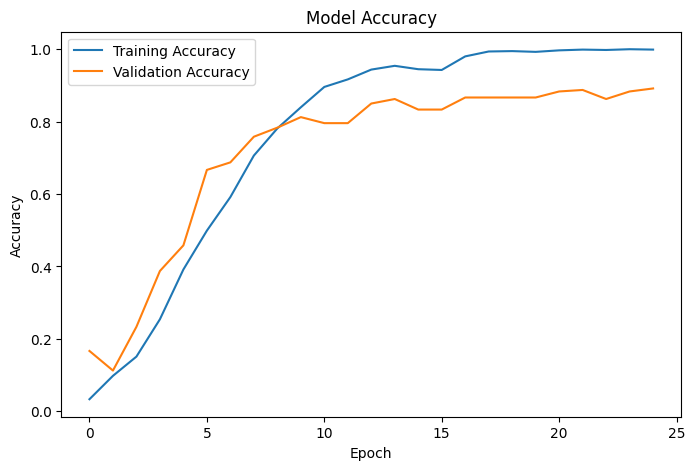

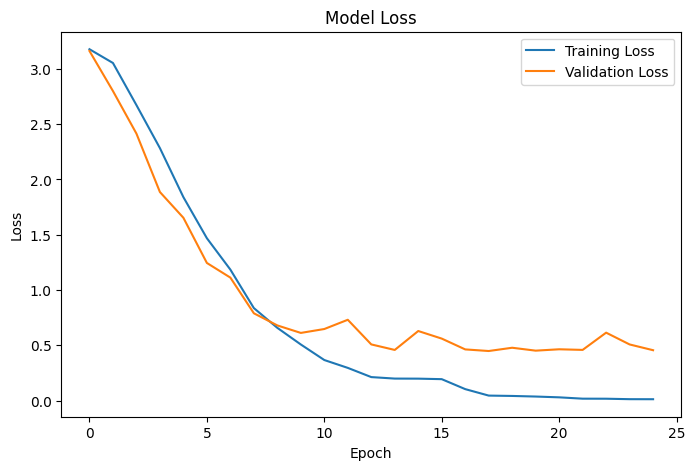

In [5]:
import matplotlib.pyplot as plt

# Plot Accuracy
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()

# Plot Loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()


In [6]:
import matplotlib.pyplot as plt

# --- ACCURACY PLOT ---
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig("accuracy_plot.png", dpi=300)   # <-- Saves the plot
plt.close()

# --- LOSS PLOT ---
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.savefig("loss_plot.png", dpi=300)      # <-- Saves the plot
plt.close()
